In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load CSV file
df = pd.read_csv("AskComputerScience.csv")

# Show first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.351874e+09,29,self.AskComputerScience,12ir20,Have any of you worked on official voting mach...,joevanwan,32,3,4,http://www.reddit.com/r/AskComputerScience/com...,With all of the speculation and fear about the...,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_12ir20,http://www.reddit.com/r/AskComputerScience/com...,NaN
1,1.320525e+09,25,self.AskComputerScience,m1paw,How do CPU and gpu architecture differ?,irishluck2012,26,1,25,http://www.reddit.com/r/AskComputerScience/com...,"I'm reading this book ""Inside the Machine"" and...",NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_m1paw,http://www.reddit.com/r/AskComputerScience/com...,NaN
2,1.319235e+09,21,self.AskComputerScience,lkf04,Why does it take computers a long time to swit...,mahkato,23,2,5,http://www.reddit.com/r/AskComputerScience/com...,What's going on that makes it take so long to ...,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_lkf04,http://www.reddit.com/r/AskComputerScience/com...,NaN
3,1.321222e+09,21,self.AskComputerScience,mb3a1,How does a computer determine something randomly?,salathiel,25,4,19,http://www.reddit.com/r/AskComputerScience/com...,NaN,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_mb3a1,http://www.reddit.com/r/AskComputerScience/com...,NaN
4,1.354788e+09,22,self.AskComputerScience,14dlpf,Could someone explain Pumping Lemma to me like...,alexgeek,22,0,7,http://www.reddit.com/r/AskComputerScience/com...,It's hurting my brain.,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_14dlpf,http://www.reddit.com/r/AskComputerScience/com...,NaN


In [3]:
# Check dataset info
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 869 entries, 0 to 868
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             869 non-null    float64
 1   score                   869 non-null    int64  
 2   domain                  869 non-null    str    
 3   id                      869 non-null    str    
 4   title                   869 non-null    str    
 5   author                  819 non-null    str    
 6   ups                     869 non-null    int64  
 7   downs                   869 non-null    int64  
 8   num_comments            869 non-null    int64  
 9   permalink               869 non-null    str    
 10  selftext                801 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 869 non-null    bool   
 13  thumbnail               0 non-null      float64
 14  subreddit_id            869 non-null    str    
 15  

created_utc                 0
score                       0
domain                      0
id                          0
title                       0
author                     50
ups                         0
downs                       0
num_comments                0
permalink                   0
selftext                   68
link_flair_text           869
over_18                     0
thumbnail                 869
subreddit_id                0
edited                      0
link_flair_css_class      869
author_flair_css_class    869
is_self                     0
name                        0
url                         0
distinguished             869
dtype: int64

In [5]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [9]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.351874e+09,29,self.AskComputerScience,12ir20,Have any of you worked on official voting mach...,joevanwan,32,3,4,http://www.reddit.com/r/AskComputerScience/com...,With all of the speculation and fear about the...,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_12ir20,http://www.reddit.com/r/AskComputerScience/com...,NaN
1,1.320525e+09,25,self.AskComputerScience,m1paw,How do CPU and gpu architecture differ?,irishluck2012,26,1,25,http://www.reddit.com/r/AskComputerScience/com...,"I'm reading this book ""Inside the Machine"" and...",NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_m1paw,http://www.reddit.com/r/AskComputerScience/com...,NaN
2,1.319235e+09,21,self.AskComputerScience,lkf04,Why does it take computers a long time to swit...,mahkato,23,2,5,http://www.reddit.com/r/AskComputerScience/com...,What's going on that makes it take so long to ...,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_lkf04,http://www.reddit.com/r/AskComputerScience/com...,NaN
3,1.321222e+09,21,self.AskComputerScience,mb3a1,How does a computer determine something randomly?,salathiel,25,4,19,http://www.reddit.com/r/AskComputerScience/com...,NaN,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_mb3a1,http://www.reddit.com/r/AskComputerScience/com...,NaN
4,1.354788e+09,22,self.AskComputerScience,14dlpf,Could someone explain Pumping Lemma to me like...,alexgeek,22,0,7,http://www.reddit.com/r/AskComputerScience/com...,It's hurting my brain.,NaN,False,NaN,t5_2shke,False,NaN,NaN,True,t3_14dlpf,http://www.reddit.com/r/AskComputerScience/com...,NaN


In [13]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [16]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Example dataset
data = {
    "age": [22, 25, 47, 52, 46, 56, 48, 55],
    "salary": [25000, 32000, 52000, 110000, 75000, 90000, 62000, 105000],
    "purchased": [0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Features (X) and target (y)
X = df[["age", "salary"]]
y = df["purchased"]

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Print results
print("Predictions:", y_pred)
print("Actual:", y_test.values)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Predictions: [0 1]
Actual: [0 1]
Accuracy: 1.0


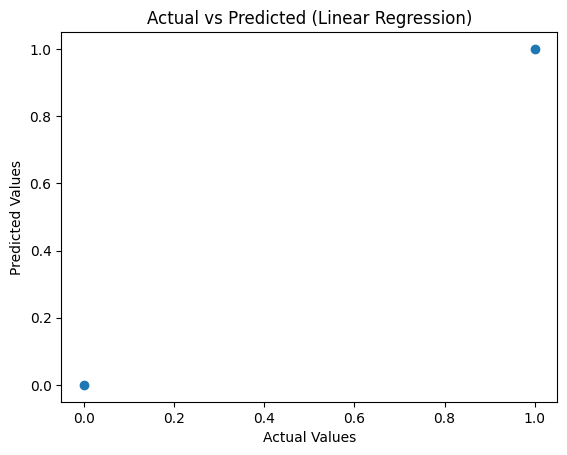

In [17]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

In [19]:
coeff_df = pd.DataFrame(model.coef_.T, index=X.columns, columns=['Coefficient'])
print(coeff_df)

        Coefficient
age       -0.000049
salary     0.001252
